<a href="https://colab.research.google.com/github/marthab-oss/Sky-Cloud-Identification/blob/main/cloud_baseline_model_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import os
from PIL import Image
from pathlib import Path
import json
import random

from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms as transforms

#to follow progres during training (train time)
from tqdm import tqdm

#for R CNN model
from torch.utils.data import DataLoader, Subset #for sample table
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
#for sample table
import matplotlib.pyplot as plt

#for test of new image on pretrained model
import cv2
from torchvision.ops import box_iou

# and for iou
from collections import namedtuple
import numpy as np

#for maP
#!pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

#for randomness
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.5 MB/s eta 0:00:00


In [36]:
#device cuda (compute unified device architecture) for google colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#pathway to drive file
from google.colab import drive
drive.mount('/content/drive')

#copy all to content, to avoid long loading time with drive mounting (once)
import shutil
if not os.path.exists('/content/Clouds-1000'):
    shutil.copytree('/content/drive/MyDrive/Clouds-1000', '/content/Clouds-1000')
else:
    #check for subfiles
    masks_ok = len(list(Path('/content/Clouds-1000/all_images_and_labels/masks').glob('*.json'))) > 100
    small_ok  = len(list(Path('/content/Clouds-1000/all_images_and_labels/images_small').glob('*.jpg'))) > 100

    if not masks_ok:
        shutil.copytree('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/masks',
                        '/content/Clouds-1000/all_images_and_labels/masks', dirs_exist_ok=True)
    if not small_ok:
        shutil.copytree('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/images_small',
                        '/content/Clouds-1000/all_images_and_labels/images_small', dirs_exist_ok=True)

print(f"Images: {len(list(Path('/content/Clouds-1000/all_images_and_labels/images_small').glob('*.jpg')))}")
print(f"Masks:  {len(list(Path('/content/Clouds-1000/all_images_and_labels/masks').glob('*.json')))}")

dir_all = Path('/content/Clouds-1000/all_images_and_labels')

#or directly load from drive
#dir_all = Path('/content/drive/MyDrive/Clouds-1000/all_images_and_labels')
image_path=dir_all/'images'
mask_path=dir_all/'masks'
small_path = Path('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/images_small')

small_path = dir_all/'images_small'

#resize all images before transform, too speed up training size/already resized
#small_path = Path('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/images_small')
#resized images already uploaded
#small_path.mkdir(exist_ok=True)
#for img_path in orig_path.glob('*.jpg'):
#    img = Image.open(img_path).convert('RGB')
#    img = img.resize((224, 224))
#    img.save(small_path / img_path.name)
image_files=list(sorted(small_path.glob('*.jpg')))
mask_files=list(sorted(mask_path.glob('*.json')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images: 996
Masks:  996


In [39]:
#baseline model: faster R CNN
#https://medium.com/@RobuRishabh/understanding-and-implementing-faster-r-cnn-248f7b25ff96

# Load the pre-trained Faster R-CNN model with a ResNet-50 backbone
model_a = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
num_classes = 6  #number of classes + background for training
in_features = model_a.roi_heads.box_predictor.cls_score.in_features #get number of input features for classifier
#change only last layer
model_a.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) #replace model's head with new one (for number of classes in dataset)

#prepare data for R CNN
# Define transformations (equal to ResNet18 baseline) & resize images for smaller data
transform = transforms.Compose([ #withoug transforms.Resize((224, 224)), as done already before loading
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), #for DataAugmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
]) #mean and std for generalized ImageNet dataset for RGB values

#create Custom Dataset to organise data in boxes/polygons and labels/classes
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, df, transforms=None):
        self.df = df
        self.transform = transforms
        self.classes = ['Arvore', 'Estratocumuliformes', 'Cirriformes', 'Estratiformes', 'Cumuliformes']
        #i+1, to let all 5 classes count, and not confound with background
        self.class_to_idx = {c: i+1 for i, c in enumerate(self.classes)}

    def __len__(self):   #detect len for batches
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['images']).convert('RGB')
        orig_w, orig_h = 2592, 1944   #from presized images (small_path), so set up original sizes here
        with open(self.df.iloc[idx]['masks']) as f:
            data = json.load(f)

        boxes, labels = [], []
        for obj in data['objects']:
            polygon = obj['points']['exterior']
            x_coords = [p[0] for p in polygon]
            y_coords = [p[1] for p in polygon]

            #to avoid unvalid boxes
            x1, y1, x2, y2 = min(x_coords), min(y_coords), max(x_coords), max(y_coords)
            if x2 <= x1 or y2 <= y1:
              continue
            boxes.append([min(x_coords), min(y_coords), max(x_coords), max(y_coords)])
            labels.append(self.class_to_idx[obj['classTitle']])

        #filter for empty boxes
        if len(boxes) == 0:
          boxes = [[0, 0, 1, 1]]
          labels = [0]

        #scale boxes to 224x224
        scale_x = 224 / orig_w
        scale_y = 224 / orig_h
        boxes = [[x1*scale_x, y1*scale_y, x2*scale_x, y2*scale_y] for x1,y1,x2,y2 in boxes]

        target = {}
        target["boxes"] = torch.tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.tensor(labels, dtype=torch.int64)

        if self.transform is not None:
            img = self.transform(img)

        return img, target



In [ ]:
print(model_a) #batchnorms are frozen, layers trainable

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
#list of all learnable parameters of r cnn model (model_a)
for name, param in model_a.named_parameters():
    print(name, param.shape)

backbone.body.conv1.weight torch.Size([64, 3, 7, 7])
backbone.body.layer1.0.conv1.weight torch.Size([64, 64, 1, 1])
backbone.body.layer1.0.conv2.weight torch.Size([64, 64, 3, 3])
backbone.body.layer1.0.conv3.weight torch.Size([256, 64, 1, 1])
backbone.body.layer1.0.downsample.0.weight torch.Size([256, 64, 1, 1])
backbone.body.layer1.1.conv1.weight torch.Size([64, 256, 1, 1])
backbone.body.layer1.1.conv2.weight torch.Size([64, 64, 3, 3])
backbone.body.layer1.1.conv3.weight torch.Size([256, 64, 1, 1])
backbone.body.layer1.2.conv1.weight torch.Size([64, 256, 1, 1])
backbone.body.layer1.2.conv2.weight torch.Size([64, 64, 3, 3])
backbone.body.layer1.2.conv3.weight torch.Size([256, 64, 1, 1])
backbone.body.layer2.0.conv1.weight torch.Size([128, 256, 1, 1])
backbone.body.layer2.0.conv2.weight torch.Size([128, 128, 3, 3])
backbone.body.layer2.0.conv3.weight torch.Size([512, 128, 1, 1])
backbone.body.layer2.0.downsample.0.weight torch.Size([512, 256, 1, 1])
backbone.body.layer2.1.conv1.weight t

In [40]:
df=pd.DataFrame({'images': image_files, 'masks': mask_files})
# split into train, val, test sets: train_size=0.7, test_size=0.15 * 2
train_df, rest_df=train_test_split(df, test_size=0.25, random_state=42) #70% train
val_df, test_df=train_test_split(rest_df, test_size=0.5, random_state=42) #je 20%

#check size
print(f"Set sizes:\nTrain:\t{len(train_df)}")
print(f"Val:\t{len(val_df)}")
print(f"Test:\t{len(test_df)}")

#load datasets
train_ds = CustomDataset(train_df, transforms=transform)
val_ds   = CustomDataset(val_df,   transforms=transform)
test_ds=CustomDataset(test_df, transforms=transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
test_loader=DataLoader(test_ds, batch_size=8, shuffle=True, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))

Set sizes:
Train:	747
Val:	124
Test:	125


In [ ]:
#to check, if boxes are succesfully resized
_, target = train_ds[0]
print("Boxes:\n",   target["boxes"])
print("Max coord:", target["boxes"].max().item())
print("Labels:",    target["labels"])

Boxes:
 tensor([[  0.0000, 156.1317, 223.9136, 223.8848],
        [  0.0000,   0.0000, 223.9136, 207.6379]])
Max coord: 223.91357421875
Labels: tensor([1, 4])


In [42]:
##implement early stopping
class EarlyStopping:
  def __init__ (self, patience=5, min_delta=0.01):
    self.patience=patience #wait on how many epochs
    self.min_delta=min_delta #smallest amount of improvement
    self.counter=0
    self.best_map=0.0

  def check(self, current_map, model, save_path):
    if current_map > self.best_map + self.min_delta:
      self.best_map=current_map
      self.counter=0
      torch.save(model.state_dict(), save_path)
      print(f'Improvement - maP: {current_map:.4f}')
      return False #continue
    else:
      self.counter+=1
      print(f'no further improvement ({self.counter}/{self.patience})')
      if self.counter >= self.patience:
        print('Early Stopping')
        return True # stop
      return False

In [43]:
#training
early_stopping=EarlyStopping(patience=5, min_delta=0.001)


model_a.to(device)

#hidden layer einfrieren: backbone layer 1 & 2
for name, param in model_a.backbone.body.named_parameters():
  if 'layer1' in name or 'layer2' in name:
    param.requires_grad=False

# Set up the optimizer
params = [p for p in model_a.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
num_epochs = 20
#lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5) #gamma 0.1 very aggressive-> to 0.5
#2nd lr scheduler variation (smoother decay):
lr_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs,eta_min=1e-6 )
for epoch in range(num_epochs):
    model_a.train()
    train_loss = 0.0

    # Training loop
    #with loading bar
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        # Forward pass
        loss_dict = model_a(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        # Backward pass
        losses.backward()
        optimizer.step()
        train_loss += losses.item()
    # Update learning rate
    lr_scheduler.step()

    #evaluate training (without gradient calculation, only prediction: no_grad)
    model_a.eval()
    ious=[]
    map_a=MeanAveragePrecision()
    with torch.no_grad():
      for images, targets in valid_loader: #targets optional as _, as it is not used here, only appearing in tupel (getitem)
        images=list(img.to(device) for img in images)
        prediction=model_a(images) #forward calculation through call

        for pred, target in zip(prediction, targets):
          preds_boxes=pred['boxes'].cpu()
          true_boxes=target['boxes'].cpu()

          if len(preds_boxes)==0 or len(true_boxes)==0: #jump over empty boxes
            continue
          iou_matrix=box_iou(preds_boxes, true_boxes)
          best_iou=iou_matrix.max(dim=1).values #choose best predicition for every original (ground truth) box
          ious.extend(best_iou.tolist())

        #for maP change to cpu (not gpu compatible)
        true_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in prediction]
        map_a.update(preds_cpu, true_cpu)
    mean_iou=sum(ious)/len(ious)
    result=map_a.compute()
    val_map=result['map'].item()

    print(f'Epoch: {epoch + 1}, Loss: {train_loss / len(train_loader)}')

    #early stopping
    if early_stopping.check(val_map, model_a, '/content/drive/MyDrive/best_model_a.pth'):
      break

print("Training complete!")
#load best model
model_a.load_state_dict(torch.load('/content/drive/MyDrive/best_model_a.pth'))
print(f"Finished with best model: mAP={early_stopping.best_map:.4f}")

Epoch 1/20: 100%|██████████| 94/94 [02:44<00:00,  1.75s/it]


Epoch: 1, Loss: 0.7374890798583944
Improvement - maP: 0.1861


Epoch 2/20: 100%|██████████| 94/94 [02:43<00:00,  1.74s/it]


Epoch: 2, Loss: 0.6850054644523783
Improvement - maP: 0.1919


Epoch 3/20: 100%|██████████| 94/94 [02:43<00:00,  1.74s/it]


...

Epoch: 18, Loss: 0.49827618294573844
Improvement - maP: 0.3096


Epoch 19/20: 100%|██████████| 94/94 [02:44<00:00,  1.75s/it]


Epoch: 19, Loss: 0.49661328960606393
no further improvement (1/5)


Epoch 20/20: 100%|██████████| 94/94 [02:43<00:00,  1.74s/it]


Epoch: 20, Loss: 0.5008479585038855
no further improvement (2/5)
Training complete!
Finished with best model: mAP=0.3096


In [ ]:
#print(f'Mean Average Prediction (maP score): {result}')
print(f'Mean Average Prediction (maP score): {result['map']:.4f}')
print(f'Mean IoU: {mean_iou}')

Mean Average Prediction (maP score): 0.1929
Mean IoU: 0.33871895144817243


In [ ]:
#check trained model success for new image
#Load random image
img = Image.open(small_path/'2021-06-03_15-46-00.jpg')
# Apply same transformation as for training
img = transform(img)
img=img.to(device)
#Model prediction
model_a.eval()
with torch.no_grad():
    prediction = model_a([img])
# Print the predicted bounding boxes and labels
print(prediction[0]['boxes'])
print(prediction[0]['labels'])

img_picture=transforms.ToPILImage() #STILL NORMALIZED!!

tensor([[0.0000e+00, 1.6425e+02, 2.2373e+02, 2.2400e+02],
        [1.3455e+01, 5.5892e+01, 2.0307e+02, 2.1437e+02],
        [2.8230e+00, 6.5301e+01, 2.1664e+02, 1.9305e+02],
        [9.6430e+00, 1.7623e+02, 1.5119e+02, 2.2263e+02],
        [1.5077e+00, 1.3048e+02, 2.0619e+02, 1.8932e+02],
        [1.1791e+01, 0.0000e+00, 2.1927e+02, 1.6128e+02],
        [1.0040e+01, 0.0000e+00, 2.2125e+02, 5.9067e+01],
        [0.0000e+00, 1.2968e+01, 2.1099e+02, 1.2846e+02],
        [9.9969e+01, 1.6886e+02, 2.2078e+02, 2.2400e+02],
        [8.7535e+00, 6.1942e+01, 2.1914e+02, 1.7851e+02],
        [3.4452e+01, 0.0000e+00, 2.0137e+02, 1.2741e+02],
        [0.0000e+00, 1.4194e+02, 1.9699e+02, 1.9576e+02],
        [0.0000e+00, 7.4176e+01, 1.5104e+02, 1.4043e+02],
        [6.3919e+01, 1.4117e+02, 2.2143e+02, 2.0102e+02],
        [6.0131e+01, 9.8744e+01, 2.0878e+02, 1.7210e+02],
        [0.0000e+00, 1.5723e+02, 1.8997e+02, 1.9738e+02],
        [1.0455e+01, 0.0000e+00, 2.1294e+02, 4.5557e+01],
        [2.602

In [ ]:
#train:80
train_df, rest_df=train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df=train_test_split(rest_df, test_size=0.5, random_state=42)
#load datasets
train_ds = CustomDataset(train_df, transforms=transform)
val_ds   = CustomDataset(val_df,   transforms=transform)
test_ds=CustomDataset(test_df, transforms=transform)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
test_loader=DataLoader(test_ds, batch_size=4, shuffle=True, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))

#check how much training data is needed for success (with map)
sample_size=[50, 100, 300, 500, len(train_df)]
map_results={}
for s in sample_size:
  print(f'Amount of Training Data: {s}')
  set_seed(42)
  sample_ds=Subset(train_ds, list(range(s)))
  sample_loader=DataLoader(sample_ds,batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

  #reinitialize model_a with subset
  model_s = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
  in_features = model_s.roi_heads.box_predictor.cls_score.in_features #get number of input features for classifier
  model_s.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) #replace model's head with new one (for number of classes in dataset)

  #hidden layer einfrieren: backbone layer 1 & 2
for name, param in model_a.backbone.body.named_parameters():
  if 'layer 1' in name or 'layer 2' in name:
    param.requires_grad=False

  model_s.to(device)
  params = [p for p in model_s.parameters() if p.requires_grad]
  optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
  lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
  num_epochs = 20
  for epoch in range(num_epochs):
      model_s.train() #no saving/later use of trainloss necessary
      # Training loop
      for images, targets in tqdm(sample_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
          images = list(image.to(device) for image in images)
          targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
          optimizer.zero_grad()
          loss_dict = model_s(images, targets)
          losses = sum(loss_dict.values())
          losses.backward()
          optimizer.step()

      # Update learning rate (when num_epochs>10)
      #lr_scheduler.step()
      print(f'Epoch: {epoch + 1}')
      print("Training complete!")

  #evaluate training (without gradient calculation, only prediction: no_grad)
  model_s.eval()
  map_s=MeanAveragePrecision()
  with torch.no_grad():
    for images, targets in valid_loader: #targets optional as _, as it is not used here, only appearing in tupel (getitem)
        images=list(img.to(device) for img in images)
        preds  = model_s(images)
        map_s.update([{k: v.cpu() for k, v in p.items()} for p in preds],
                [{k: v.cpu() for k, v in t.items()} for t in targets]
            )
  result_s=map_s.compute()
  map_results[s] = result_s['map'].item()
  print(f'Amount={s}: maP = {map_results[s]:.4f}')

Amount of Training Data: 50


Epoch 1/3: 100%|██████████| 13/13 [00:24<00:00,  1.88s/it]


Epoch: 1
Training complete!


Epoch 2/3: 100%|██████████| 13/13 [00:05<00:00,  2.59it/s]


Epoch: 2
Training complete!


...

Epoch: 1
Training complete!


Epoch 2/3: 100%|██████████| 199/199 [01:20<00:00,  2.46it/s]


Epoch: 2
Training complete!


Epoch 3/3: 100%|██████████| 199/199 [01:20<00:00,  2.46it/s]


Epoch: 3
Training complete!
Amount=796: maP = 0.1729


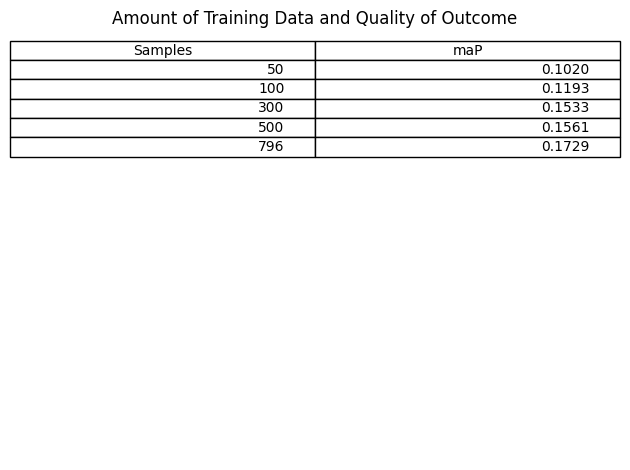

In [ ]:
#print table
table_data=[]
for s,m in map_results.items():
  table_data.append([s, f'{m:.4f}'])

fig, ax = plt.subplots() #figsize=(10, 7)
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=['Samples', 'maP'], loc='upper center')
ax.set_title('Amount of Training Data and Quality of Outcome') #fontsize=12, fontweight='bold'
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Clouds-1000/Performance_SampleSize_table.jpeg')
plt.show()

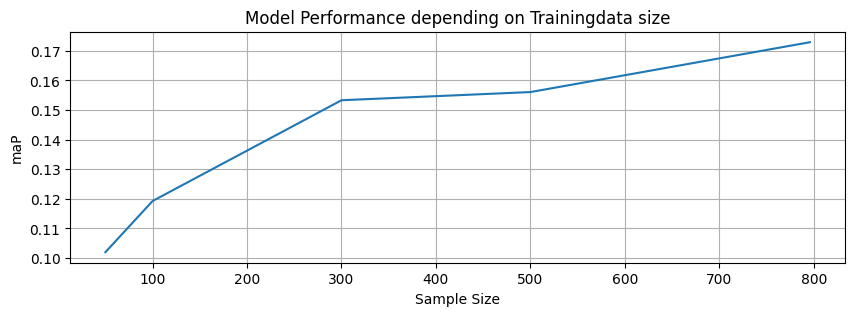

In [ ]:
#visualitze table
plt.figure(figsize=(10,3))
plt.plot(list(map_results.keys()), list(map_results.values()))
plt.title('Model Performance depending on Trainingdata size')
plt.xlabel('Sample Size')
plt.ylabel('maP')
plt.grid(True)
#plt.savefig('/content/drive/MyDrive/Clouds-1000/Performance_SampleSize.jpeg')
plt.show()